# Data Visualization Lab — Sample Superstore

**Important:** This notebook uses the **original Sample Superstore dataset**. No duplicate rows are removed and no rows are dropped for missing values. Date columns are converted to datetime only so that the time-based charts can be plotted.


In [5]:
import pandas as pd

path = r"C:\Users\Rayhab\Downloads\superstore.csv"

df = pd.read_csv(path, encoding="latin1")

print(df.shape)
display(df.head())

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Missing values:")
display(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values:


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


# Task 1 — Same data, multiple chart types

Aggregate total Sales by month, then show the same monthly totals using a bar chart, line chart, and pie chart.


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

monthly_sales = (
    df.assign(Month=df["Order Date"].dt.to_period("M"))
      .groupby("Month", as_index=False)["Sales"].sum()
)

monthly_sales["Month"] = monthly_sales["Month"].dt.to_timestamp()

display(monthly_sales)

,Month,Sales
0,2014-01-01,14236.8950
1,2014-02-01,4519.8920
2,2014-03-01,55691.0090
3,2014-04-01,28295.3450
4,2014-05-01,23648.2870
5,2014-06-01,34595.1276
6,2014-07-01,33946.3930
7,2014-08-01,27909.4685
8,2014-09-01,81777.3508
9,2014-10-01,31453.3930


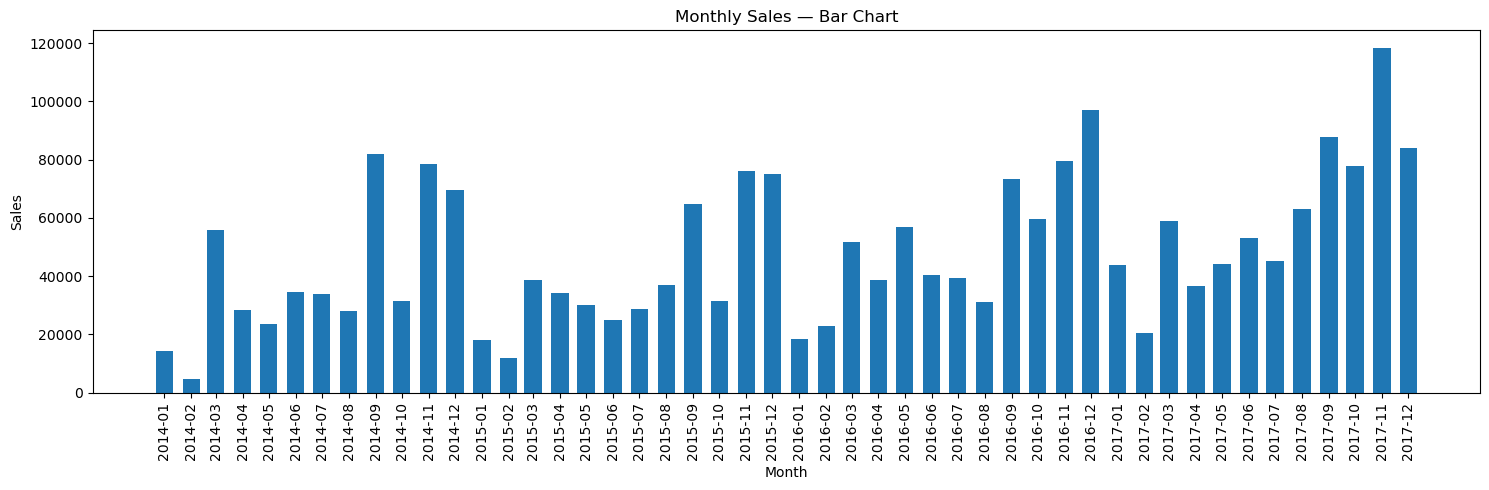

In [30]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(monthly_sales["Month"], monthly_sales["Sales"], width=20)
ax.set_xticks(
    monthly_sales["Month"]
)  # Force a tick for every single data point
ax.set_xticklabels(
    monthly_sales["Month"].dt.strftime("%Y-%m"), rotation=90
)
ax.set_title("Monthly Sales — Bar Chart")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

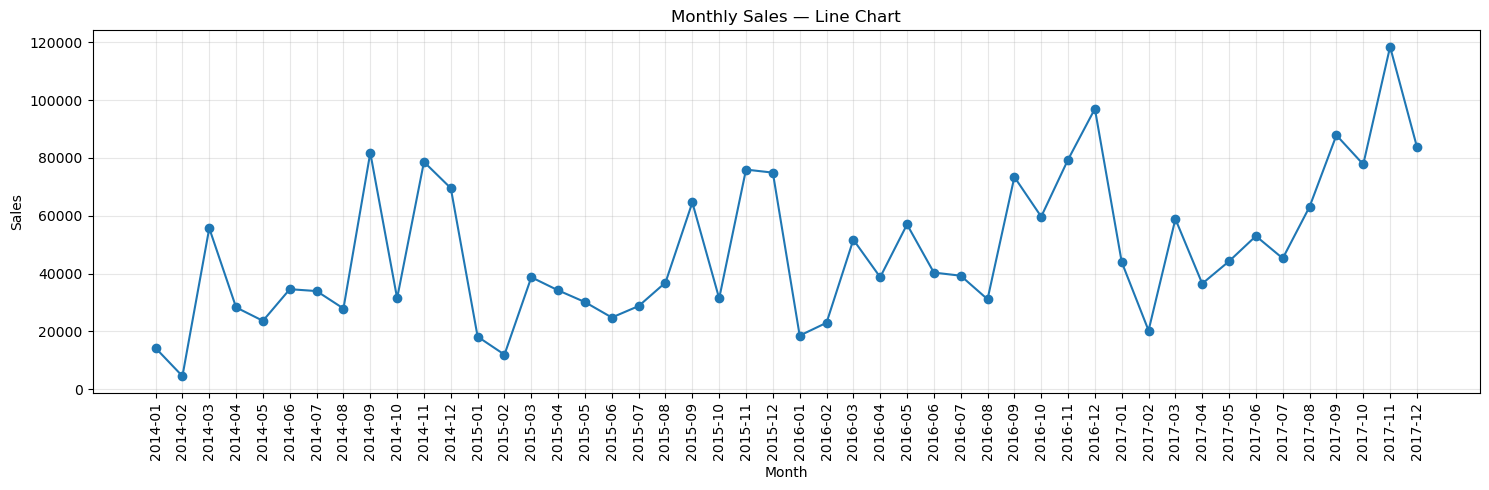

In [32]:
# Convert the Month column to formatted strings
monthly_sales["Month_Str"] = monthly_sales["Month"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_sales["Month_Str"], monthly_sales["Sales"], marker="o")
ax.set_title("Monthly Sales — Line Chart")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=90)  # Rotated 90 degrees to fit all labels
plt.tight_layout()
plt.show()

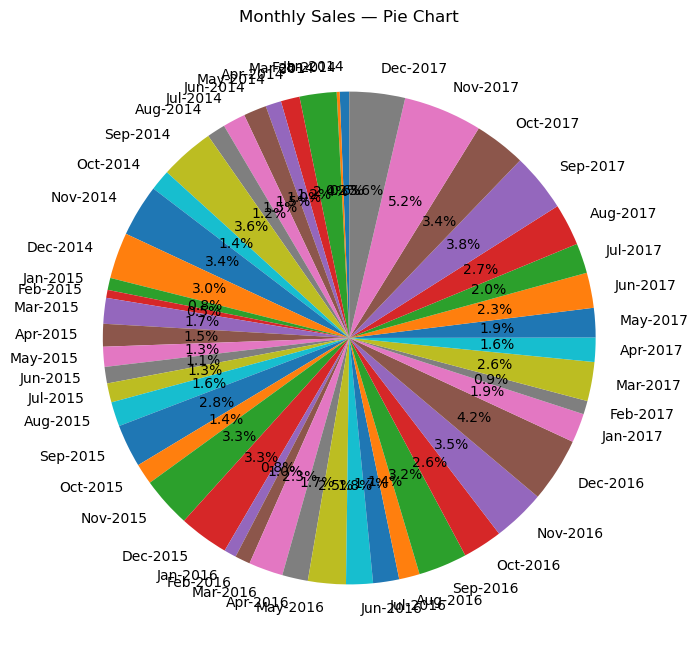

In [11]:
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(monthly_sales["Sales"],
       labels=monthly_sales["Month"].dt.strftime("%b-%Y"),
       autopct="%1.1f%%", startangle=90)
ax.set_title("Monthly Sales — Pie Chart")
plt.show()


### Answer

**The line chart shows the trend best** because connecting monthly observations makes increases, decreases, peaks, and dips easy to follow.

**The pie chart hides the trend** because it represents months as parts of a whole rather than as an ordered time sequence. With many slices, precise comparison is also difficult.


# Task 2 — Effectiveness & appropriateness

,Sub-Category,Sales
3,Binders,203412.733
16,Tables,206965.532
14,Storage,223843.608
5,Chairs,328449.103
13,Phones,330007.054


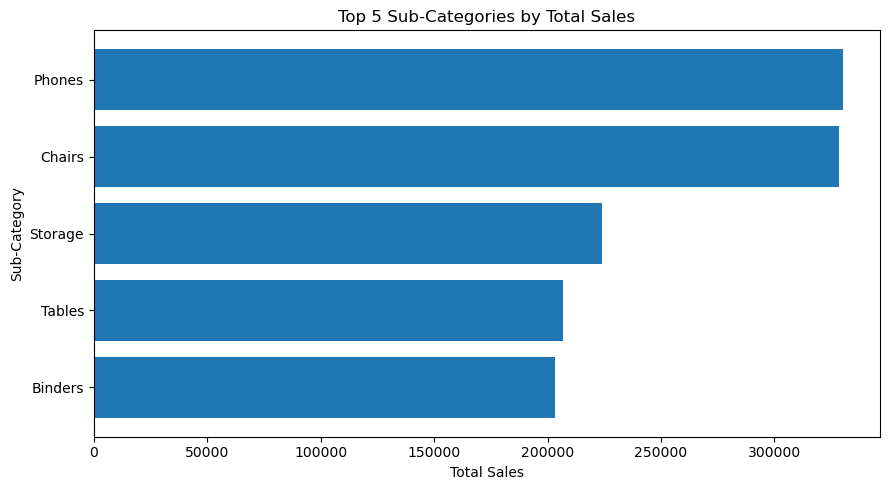

In [12]:
# Compare total sales across the top 5 sub-categories
top5 = (
    df.groupby("Sub-Category", as_index=False)["Sales"].sum()
      .sort_values("Sales", ascending=False)
      .head(5)
      .sort_values("Sales")
)

display(top5)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(top5["Sub-Category"], top5["Sales"])
ax.set_title("Top 5 Sub-Categories by Total Sales")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Sub-Category")
plt.tight_layout()
plt.show()


**Justification:** A horizontal bar chart is best for comparing category magnitudes because the bar lengths share a common baseline. A pie chart would make precise comparisons between similar-sized categories harder.


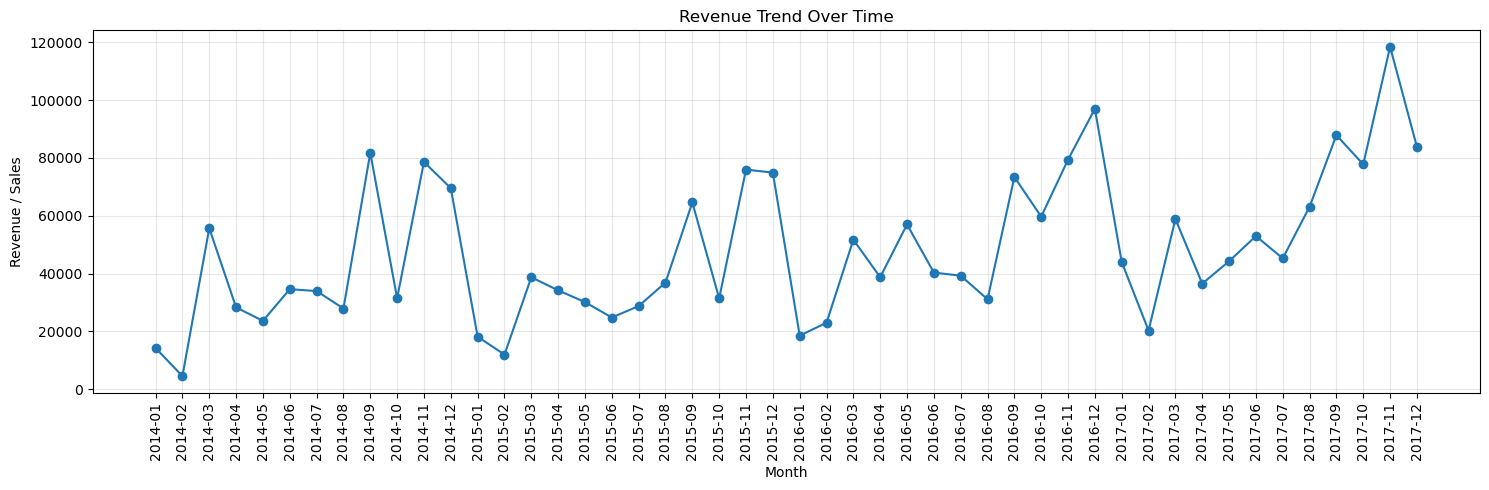

In [33]:
# Convert the Month column to formatted strings
monthly_sales["Month_Str"] = monthly_sales["Month"].dt.strftime("%Y-%m")

# Show revenue trend over time
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_sales["Month_Str"], monthly_sales["Sales"], marker="o")
ax.set_title("Revenue Trend Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue / Sales")
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=90)  # Rotated 90 degrees to fit all labels
plt.tight_layout()
plt.show()

**Justification:** A line chart is appropriate for time-series data because the connected points emphasize the chronological trend. A bar chart becomes visually heavier when many time periods are shown.


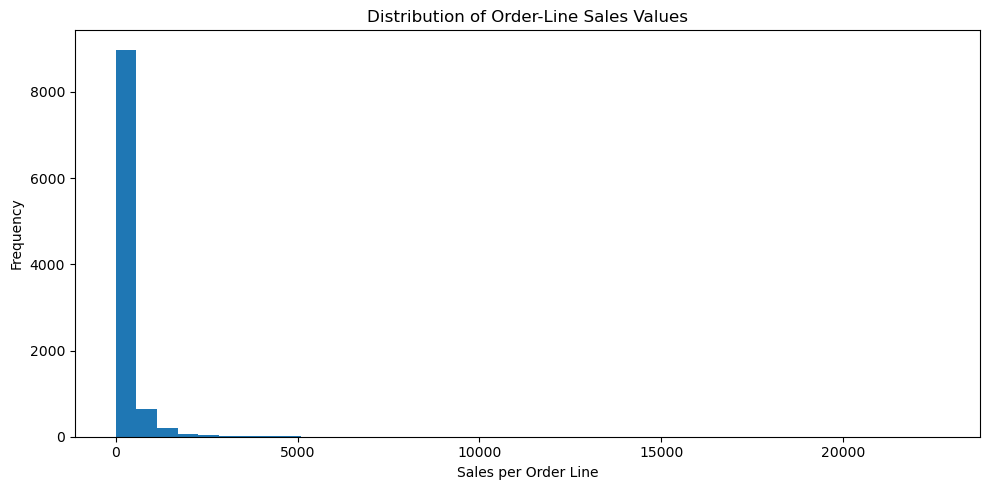

In [14]:
# Show distribution of raw order-line Sales values
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df["Sales"], bins=40)
ax.set_title("Distribution of Order-Line Sales Values")
ax.set_xlabel("Sales per Order Line")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Justification:** A histogram is appropriate because it shows the distribution, spread, concentration, and skewness of the raw Sales values. A bar chart of averages would hide this information.


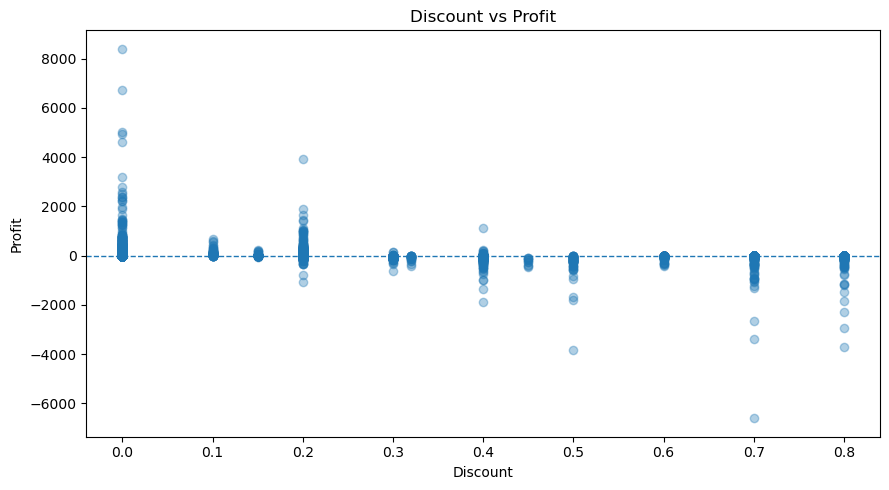

In [15]:
# Show relationship between raw Discount and Profit
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(df["Discount"], df["Profit"], alpha=0.35)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
plt.tight_layout()
plt.show()


**Justification:** A scatter plot is suitable because both variables are quantitative and the goal is to examine their relationship. A line chart would imply an ordered sequence that does not exist between individual discount/profit observations.


# Task 3 — Color selection

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


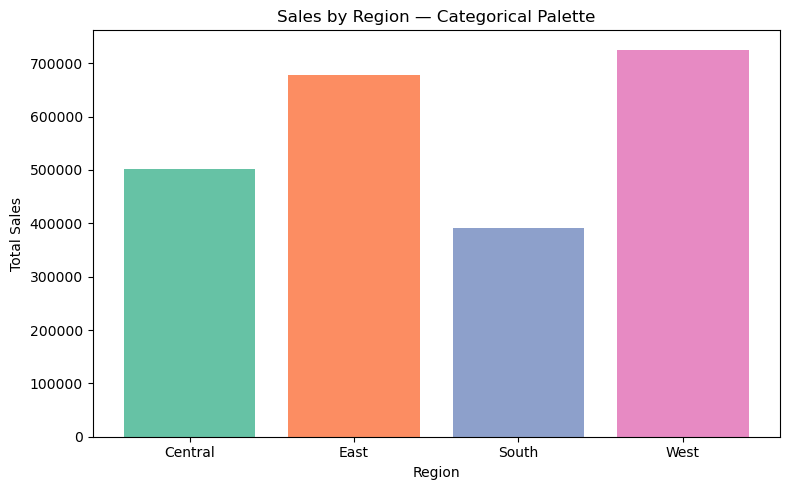

In [16]:
# 3(a) Region sales — categorical palette
region_sales = df.groupby("Region", as_index=False)["Sales"].sum()
display(region_sales)

fig, ax = plt.subplots(figsize=(8,5))
palette = sns.color_palette("Set2", n_colors=len(region_sales))
ax.bar(region_sales["Region"], region_sales["Sales"], color=palette)
ax.set_title("Sales by Region — Categorical Palette")
ax.set_xlabel("Region")
ax.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()


Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


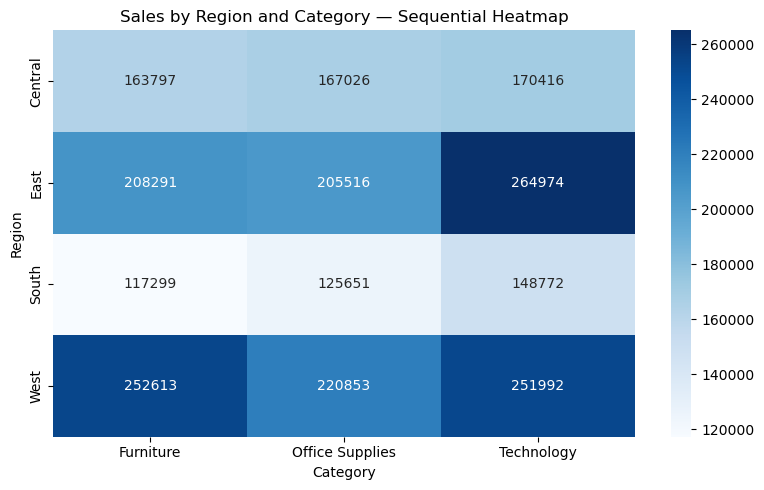

In [17]:
# 3(b) Region x Category — sequential heatmap
region_category = pd.pivot_table(
    df, values="Sales", index="Region", columns="Category", aggfunc="sum"
)
display(region_category)

plt.figure(figsize=(8,5))
sns.heatmap(region_category, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Region and Category — Sequential Heatmap")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


,Month,Profit
0,2014-01-01,2450.1907
1,2014-02-01,862.3084
2,2014-03-01,498.7299
3,2014-04-01,3488.8352
4,2014-05-01,2738.7096
5,2014-06-01,4976.5244
6,2014-07-01,-841.4826
7,2014-08-01,5318.1050
8,2014-09-01,8328.0994
9,2014-10-01,3448.2573


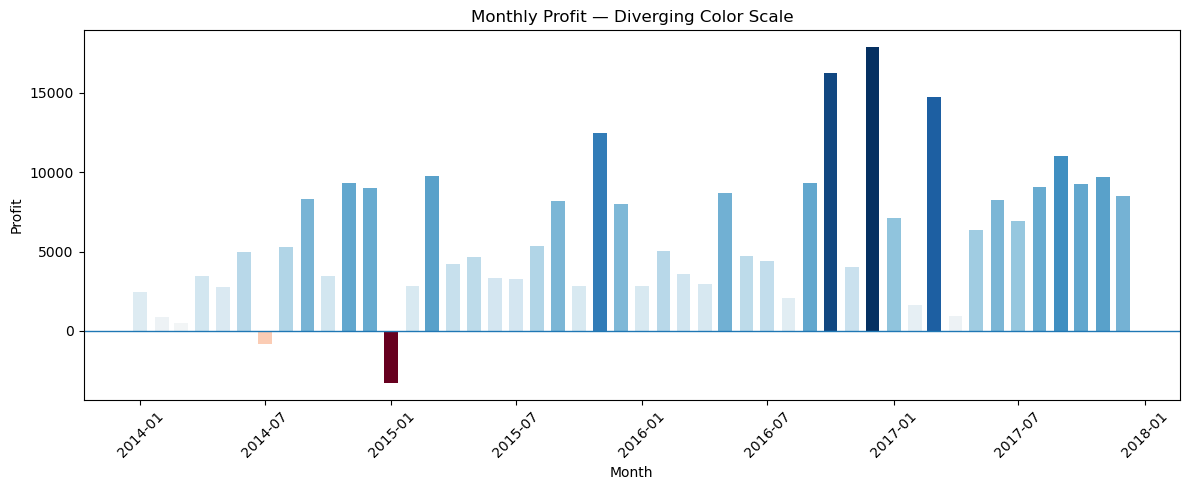

In [18]:
# 3(c) Monthly profit — diverging color scale centered at zero
monthly_profit = (
    df.assign(Month=df["Order Date"].dt.to_period("M"))
      .groupby("Month", as_index=False)["Profit"].sum()
)
monthly_profit["Month"] = monthly_profit["Month"].dt.to_timestamp()
display(monthly_profit)

fig, ax = plt.subplots(figsize=(12,5))
norm = TwoSlopeNorm(vmin=monthly_profit["Profit"].min(),
                    vcenter=0,
                    vmax=monthly_profit["Profit"].max())
colors = plt.cm.RdBu(norm(monthly_profit["Profit"]))

ax.bar(monthly_profit["Month"], monthly_profit["Profit"],
       color=colors, width=20)
ax.axhline(0, linewidth=1)
ax.set_title("Monthly Profit — Diverging Color Scale")
ax.set_xlabel("Month")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


# Task 4 — WCAG contrast ratio

In [19]:
def relative_luminance(rgb):
    rgb = np.array(rgb, dtype=float) / 255.0
    rgb_linear = np.where(
        rgb <= 0.03928,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )
    return (
        0.2126 * rgb_linear[0]
        + 0.7152 * rgb_linear[1]
        + 0.0722 * rgb_linear[2]
    )

def contrast_ratio(rgb1, rgb2):
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter = max(l1, l2)
    darker = min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

# Test examples
print("Black on white:", round(contrast_ratio((0,0,0),(255,255,255)), 2))
print("Gray on white:", round(contrast_ratio((150,150,150),(255,255,255)), 2))


Black on white: 21.0
Gray on white: 2.96


In [20]:
# Test Task 3(a) palette against white
rgb_palette = [
    tuple(round(v*255) for v in plt.matplotlib.colors.to_rgb(c))
    for c in palette
]

for i, rgb in enumerate(rgb_palette, start=1):
    ratio = contrast_ratio(rgb, (255,255,255))
    print(
        f"Color {i}: RGB={rgb}, contrast={ratio:.2f}:1 ->",
        "PASS" if ratio >= 4.5 else "FAIL"
    )


Color 1: RGB=(102, 194, 165), contrast=2.14:1 -> FAIL
Color 2: RGB=(252, 141, 98), contrast=2.30:1 -> FAIL
Color 3: RGB=(141, 160, 203), contrast=2.62:1 -> FAIL
Color 4: RGB=(231, 138, 195), contrast=2.38:1 -> FAIL


## Task 4(b) — Red/green accessibility problem

The next chart deliberately uses **red and green only** for loss vs gain. Run the instructor-provided colorblind simulator on this chart and take the required before/after screenshot.


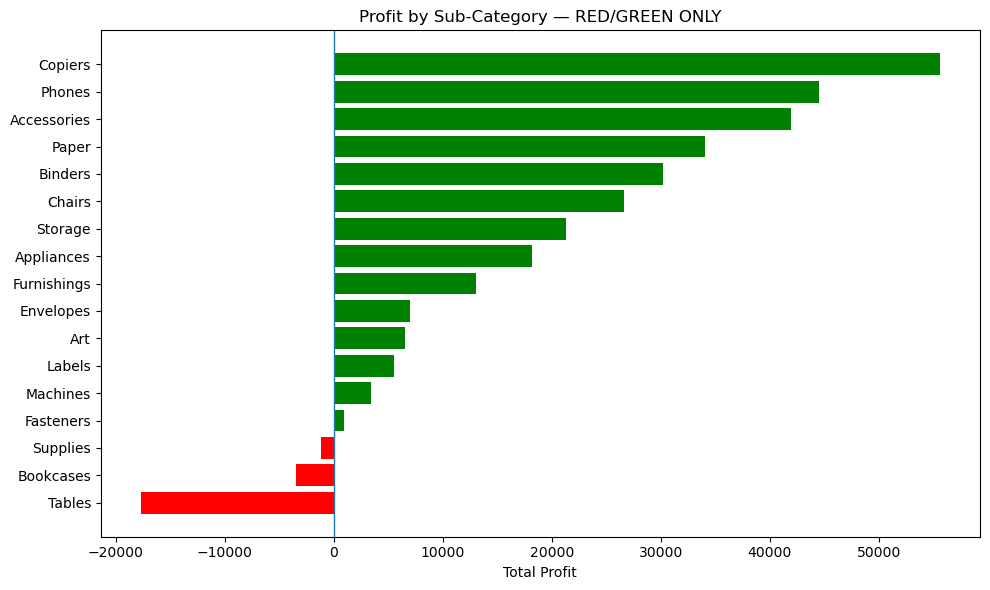

In [21]:
profit_subcat = (
    df.groupby("Sub-Category", as_index=False)["Profit"].sum()
      .sort_values("Profit")
)

# Intentionally inaccessible version
fig, ax = plt.subplots(figsize=(10,6))
rg_colors = ["green" if x >= 0 else "red"
             for x in profit_subcat["Profit"]]

ax.barh(profit_subcat["Sub-Category"],
        profit_subcat["Profit"],
        color=rg_colors)
ax.axvline(0, linewidth=1)
ax.set_title("Profit by Sub-Category — RED/GREEN ONLY")
ax.set_xlabel("Total Profit")
plt.tight_layout()
plt.show()


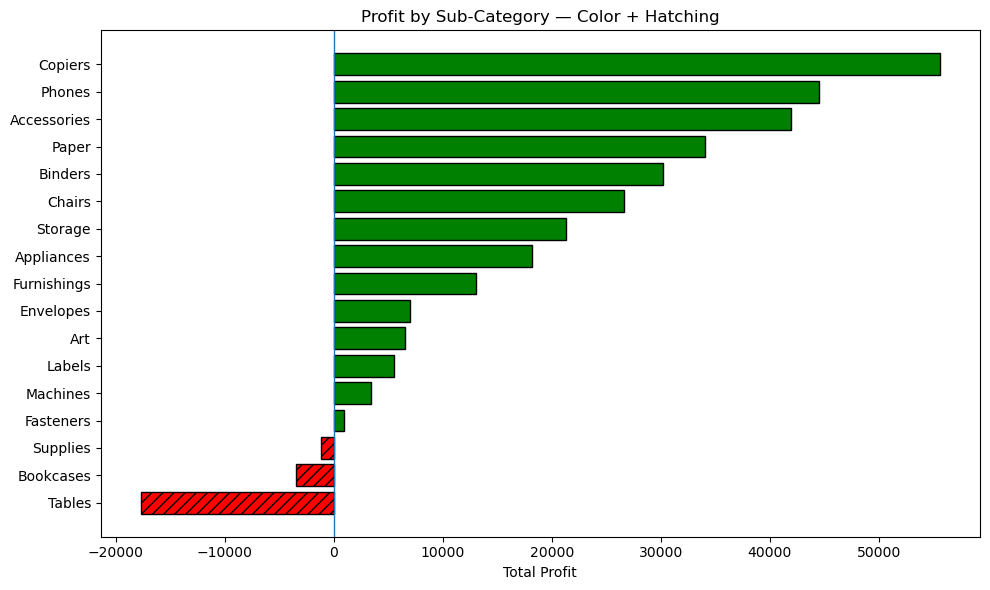

In [22]:
# Accessible fix: color + hatching
fig, ax = plt.subplots(figsize=(10,6))

for i, value in enumerate(profit_subcat["Profit"]):
    if value < 0:
        ax.barh(
            profit_subcat["Sub-Category"].iloc[i],
            value,
            color="red",
            hatch="///",
            edgecolor="black"
        )
    else:
        ax.barh(
            profit_subcat["Sub-Category"].iloc[i],
            value,
            color="green",
            edgecolor="black"
        )

ax.axvline(0, linewidth=1)
ax.set_title("Profit by Sub-Category — Color + Hatching")
ax.set_xlabel("Total Profit")
plt.tight_layout()
plt.show()


**Alt text:** Horizontal bar chart of total profit by sub-category; positive profits extend right and negative profits extend left, with losses additionally marked by diagonal hatching so the distinction does not depend on color alone.


# Task 5 — Misleading visualizations

Below are five options; the lab requires at least three. You can submit all five.


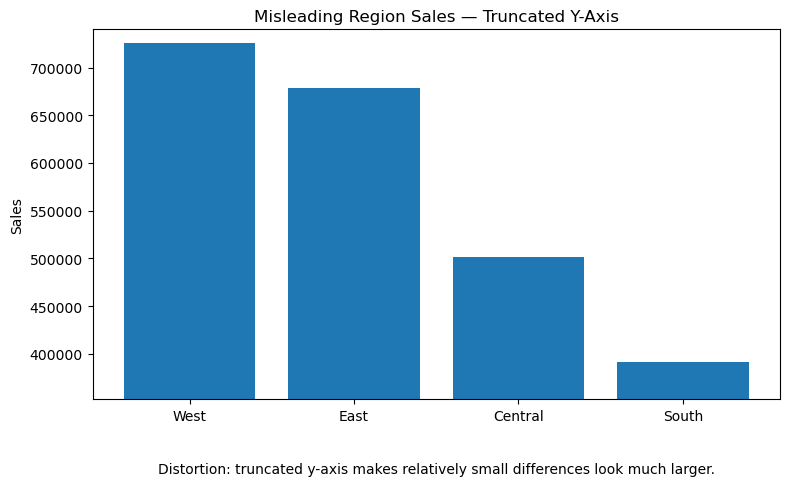

In [23]:
# 5.1 Truncated y-axis
rs = region_sales.sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(rs["Region"], rs["Sales"])
ax.set_ylim(rs["Sales"].min() * 0.90, rs["Sales"].max() * 1.02)
ax.set_title("Misleading Region Sales — Truncated Y-Axis")
ax.set_ylabel("Sales")
ax.text(
    0.5, -0.20,
    "Distortion: truncated y-axis makes relatively small differences look much larger.",
    transform=ax.transAxes, ha="center"
)
plt.tight_layout()
plt.show()


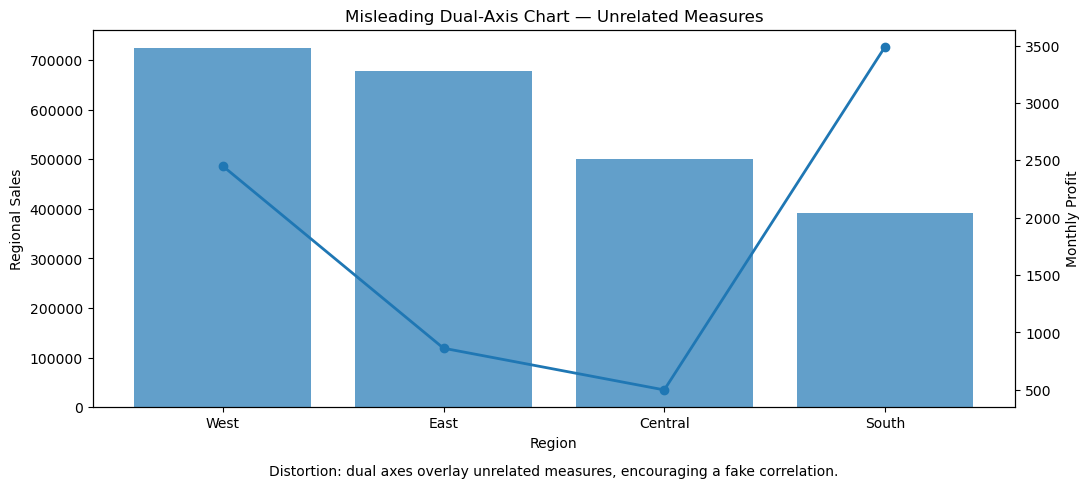

In [24]:
# 5.2 Dual-axis chart using unrelated measures
fig, ax1 = plt.subplots(figsize=(11,5))

ax1.bar(rs["Region"], rs["Sales"], alpha=0.7)
ax1.set_xlabel("Region")
ax1.set_ylabel("Regional Sales")

ax2 = ax1.twinx()
mp = monthly_profit.head(len(rs))
ax2.plot(rs["Region"], mp["Profit"], marker="o", linewidth=2)
ax2.set_ylabel("Monthly Profit")

plt.title("Misleading Dual-Axis Chart — Unrelated Measures")
plt.text(
    0.5, -0.18,
    "Distortion: dual axes overlay unrelated measures, encouraging a fake correlation.",
    transform=ax1.transAxes, ha="center"
)
plt.tight_layout()
plt.show()


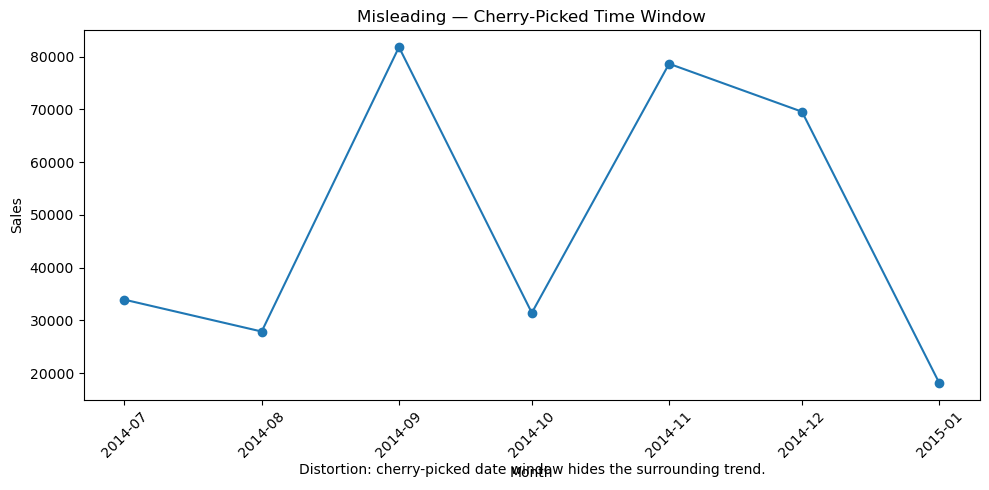

In [25]:
# 5.3 Cherry-picked date window
cherry = monthly_sales.iloc[6:13]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(cherry["Month"], cherry["Sales"], marker="o")
ax.set_title("Misleading — Cherry-Picked Time Window")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.text(
    0.5, -0.20,
    "Distortion: cherry-picked date window hides the surrounding trend.",
    transform=ax.transAxes, ha="center"
)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


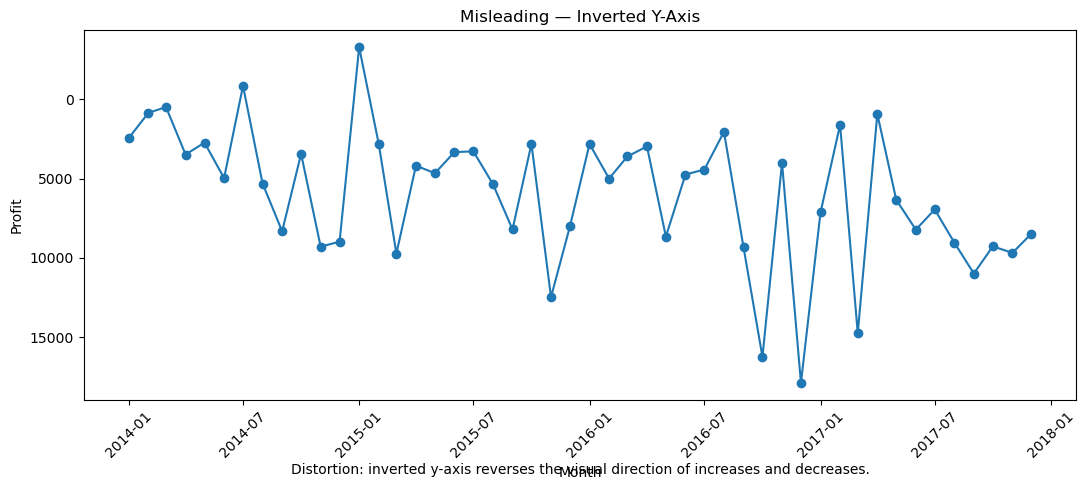

In [26]:
# 5.4 Inverted y-axis
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(monthly_profit["Month"], monthly_profit["Profit"], marker="o")
ax.invert_yaxis()
ax.set_title("Misleading — Inverted Y-Axis")
ax.set_xlabel("Month")
ax.set_ylabel("Profit")
ax.text(
    0.5, -0.20,
    "Distortion: inverted y-axis reverses the visual direction of increases and decreases.",
    transform=ax.transAxes, ha="center"
)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


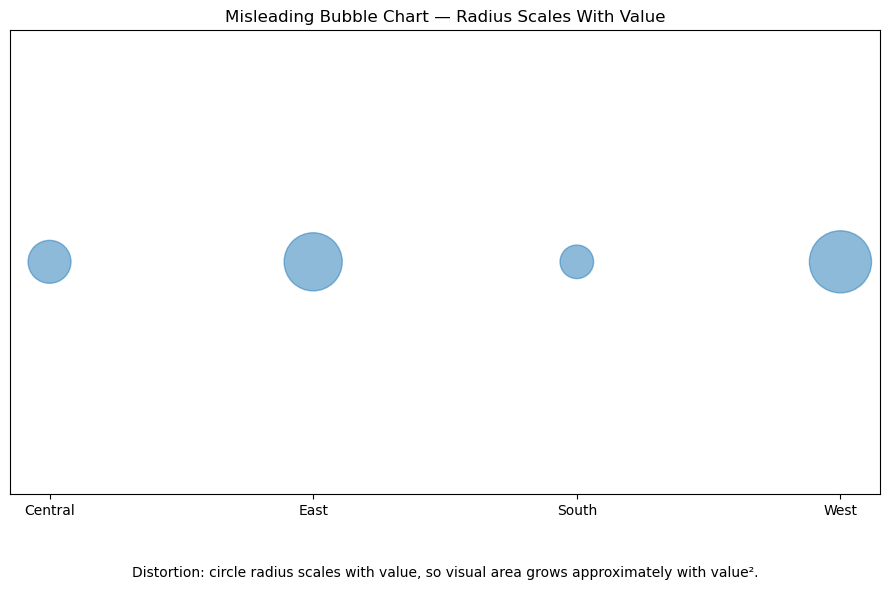

In [27]:
# 5.5 Bubble chart — radius, rather than area, scales with value
bubble = region_sales.copy()
bubble["RadiusScale"] = bubble["Sales"] / bubble["Sales"].max()
bubble["MarkerArea"] = 2000 * bubble["RadiusScale"] ** 2

fig, ax = plt.subplots(figsize=(9,6))
x = np.arange(len(bubble))
ax.scatter(x, np.zeros(len(bubble)),
           s=bubble["MarkerArea"], alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(bubble["Region"])
ax.set_yticks([])
ax.set_title("Misleading Bubble Chart — Radius Scales With Value")
ax.text(
    0.5, -0.18,
    "Distortion: circle radius scales with value, so visual area grows approximately with value².",
    transform=ax.transAxes, ha="center"
)
plt.tight_layout()
plt.show()


# Task 6 — Analytical question

### Question: Is discounting associated with lower profit?

We use the raw `Discount` and `Profit` columns directly.


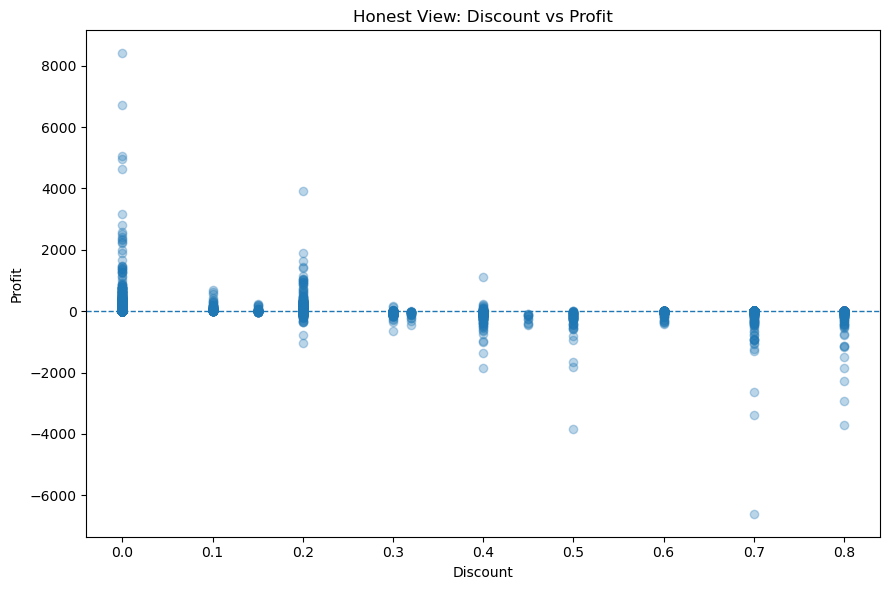

In [28]:
# Honest visualization
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(df["Discount"], df["Profit"], alpha=0.30)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Honest View: Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
plt.tight_layout()
plt.show()


### Honest-chart justification

A **scatter plot** is appropriate because Discount and Profit are quantitative variables and the question asks about their relationship. The full set of observations is retained, so the viewer can see variation rather than only a summary.

The color design does not rely on red vs green, and the zero-profit reference is distinguished using a dashed line. Axis labels provide the exact variables being compared.


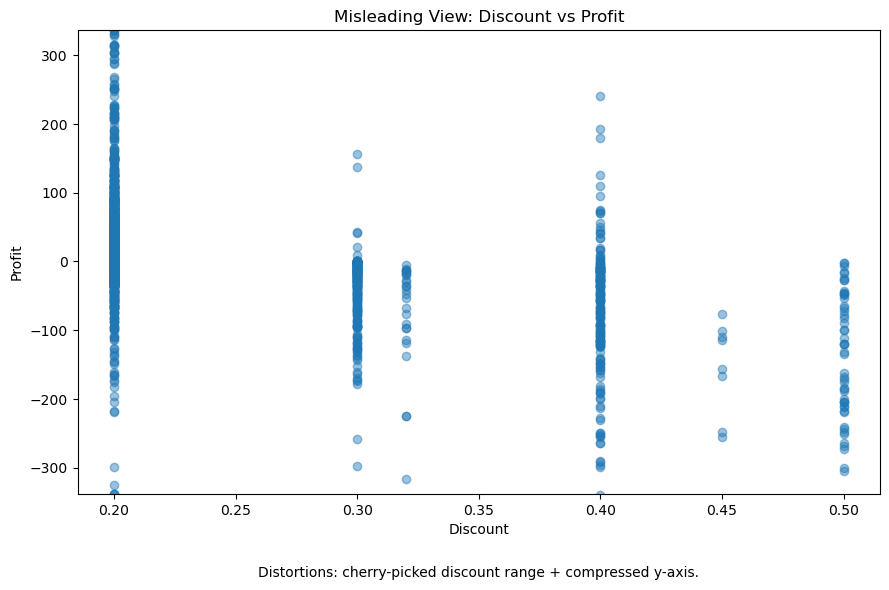

In [29]:
# Deliberately misleading visualization
# Select only a narrow discount range and compress the y-axis.
subset = df[(df["Discount"] >= 0.20) & (df["Discount"] <= 0.50)].copy()

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(subset["Discount"], subset["Profit"], alpha=0.45)

q1, q99 = subset["Profit"].quantile([0.01, 0.99])
ax.set_ylim(q1, q99)

ax.set_title("Misleading View: Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
ax.text(
    0.5, -0.18,
    "Distortions: cherry-picked discount range + compressed y-axis.",
    transform=ax.transAxes, ha="center"
)
plt.tight_layout()
plt.show()


### Misleading-chart justification

The misleading version removes observations outside a selected discount range and compresses the y-axis, which can exaggerate the apparent relationship. It therefore gives a less honest impression than the full-data scatter plot.

The honest chart is preferable because it represents the available evidence without selectively hiding observations or manipulating the visual scale.
